## Project Setup and Data Pipeline (Step 1)

In [1]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the base project path as specified
PROJECT_BASE_PATH = '/content/drive/MyDrive/CNNs and Transfer Learning'

# Create project directories if they don't exist
os.makedirs(PROJECT_BASE_PATH, exist_ok=True)

# Define subdirectories
DATA_PATH = os.path.join(PROJECT_BASE_PATH, 'data')
MODELS_PATH = os.path.join(PROJECT_BASE_PATH, 'models')
OUTPUTS_PATH = os.path.join(PROJECT_BASE_PATH, 'outputs')
LOGS_PATH = os.path.join(PROJECT_BASE_PATH, 'logs')
CONFIGS_PATH = os.path.join(PROJECT_BASE_PATH, 'configs')

# Create subdirectories
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(OUTPUTS_PATH, exist_ok=True)
os.makedirs(LOGS_PATH, exist_ok=True)
os.makedirs(CONFIGS_PATH, exist_ok=True)

print(f"Project base path: {PROJECT_BASE_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Models path: {MODELS_PATH}")
print(f"Outputs path: {OUTPUTS_PATH}")
print(f"Logs path: {LOGS_PATH}")
print(f"Configs path: {CONFIGS_PATH}")

print("Project directory structure created successfully.")


Mounted at /content/drive
Project base path: /content/drive/MyDrive/CNNs and Transfer Learning
Data path: /content/drive/MyDrive/CNNs and Transfer Learning/data
Models path: /content/drive/MyDrive/CNNs and Transfer Learning/models
Outputs path: /content/drive/MyDrive/CNNs and Transfer Learning/outputs
Logs path: /content/drive/MyDrive/CNNs and Transfer Learning/logs
Configs path: /content/drive/MyDrive/CNNs and Transfer Learning/configs
Project directory structure created successfully.


### Data Loading and Preprocessing

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Define ImageNet mean and standard deviation for normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def get_white_padded_centered_crop(pil_image):
    # 1. Convert PIL to OpenCV (BGR)
    cv_img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    img_h, img_w = cv_img.shape[:2]
    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

    # 2. Precise Segmentation
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Create Safety Buffer Mask
    kernel = np.ones((5, 5), np.uint8)
    leaf_mask = cv2.dilate(thresh, kernel, iterations=2)

    # 4. White Background Replacement
    white_bg = np.full(cv_img.shape, 255, dtype=np.uint8)

    cv_img_cleaned = np.where(leaf_mask[:, :, None] == 255, cv_img, white_bg)

    # 5. Find Object Bounding Box (using original thresh for accuracy)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return pil_image

    largest_cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_cnt)

    # 6. Configure 1:1 Square with 2% Margin
    max_dim = max(w, h)
    small_margin = int(max_dim * 0.02)
    square_side = max_dim + (2 * small_margin)

    # 7. Create Large Canvas and Center the Cleaned Image
    canvas_side = max(img_w, img_h) + (square_side * 2)
    canvas = np.full((canvas_side, canvas_side, 3), 255, dtype=np.uint8)

    off_x = (canvas_side - img_w) // 2
    off_y = (canvas_side - img_h) // 2
    canvas[off_y:off_y+img_h, off_x:off_x+img_w] = cv_img_cleaned

    # 8. Final Centered Crop
    obj_center_x = off_x + x + (w // 2)
    obj_center_y = off_y + y + (h // 2)

    left = obj_center_x - (square_side // 2)
    top = obj_center_y - (square_side // 2)

    final_crop = canvas[top:top+square_side, left:left+square_side]

    return Image.fromarray(cv2.cvtColor(final_crop, cv2.COLOR_BGR2RGB))


# Define transformations
train_transforms = transforms.Compose([
    transforms.Lambda(get_white_padded_centered_crop), # Apply custom preprocessing first
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20, fill=255), # Added fill=255 here
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10), # Optional
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Lambda(get_white_padded_centered_crop), # Apply custom preprocessing first
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Load the dataset using ImageFolder
# Assuming the dataset is structured as: data/class1/img1.jpg, data/class2/img2.jpg, etc.
# The `DATA_PATH` should contain subfolders named after each class (e.g., 'algal leaf', 'brown blight', 'white spot').
full_dataset = datasets.ImageFolder(root=DATA_PATH)

# Check if the dataset is empty
if len(full_dataset) == 0:
    raise ValueError(f"No images found in the specified data path: {DATA_PATH}. Please ensure your data is correctly placed and structured (e.g., {DATA_PATH}/class_name/image.jpg).")

# Get targets for stratified split
targets = np.array(full_dataset.targets)

# Stratified split 60/20/20
# First split: 80% for train_val, 20% for test
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_val_original_idx, test_original_idx in split1.split(np.zeros(len(targets)), targets):
    # train_val_original_idx contains indices relative to full_dataset
    # test_original_idx contains indices relative to full_dataset

    train_val_subset_indices = train_val_original_idx # These are indices into full_dataset
    train_val_targets = targets[train_val_subset_indices]

# Second split: 75% of train_val for train, 25% for val (which is 60% train, 20% val of total)
split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED) # 0.25 of 0.8 is 0.2
for train_relative_idx_in_train_val, val_relative_idx_in_train_val in split2.split(np.zeros(len(train_val_targets)), train_val_targets):
    # These indices are relative to train_val_subset_indices
    pass # We just need the indices

# Now, map these relative indices back to the original full_dataset indices
train_final_indices = train_val_subset_indices[train_relative_idx_in_train_val]
val_final_indices = train_val_subset_indices[val_relative_idx_in_train_val]
test_final_indices = test_original_idx

# Create full datasets with respective transforms
train_full_dataset_with_transforms = datasets.ImageFolder(root=DATA_PATH, transform=train_transforms)
val_full_dataset_with_transforms = datasets.ImageFolder(root=DATA_PATH, transform=val_test_transforms)
test_full_dataset_with_transforms = datasets.ImageFolder(root=DATA_PATH, transform=val_test_transforms)

# Create final subsets using the full datasets with transforms and the mapped indices
train_dataset = Subset(train_full_dataset_with_transforms, train_final_indices)
val_dataset = Subset(val_full_dataset_with_transforms, val_final_indices)
test_dataset = Subset(test_full_dataset_with_transforms, test_final_indices)


print(f"Total dataset size: {len(full_dataset)}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

class_names = full_dataset.classes
print(f"Class names: {class_names}")

# --- Class Imbalance Check and Statistics ---
def get_class_distribution(dataset, class_names):
    # For Subset, need to map back to original dataset's targets
    if isinstance(dataset, Subset):
        # Access the targets from the base dataset of the subset using its indices
        targets_from_base_dataset = np.array(dataset.dataset.targets)
        subset_targets = targets_from_base_dataset[dataset.indices]
    else:
        subset_targets = np.array(dataset.targets)

    class_counts = {class_names[i]: np.sum(subset_targets == i) for i in range(len(class_names))}
    total_samples = len(subset_targets)
    print(f"  Total samples: {total_samples}")
    for class_name, count in class_counts.items():
        percentage = (count / total_samples) * 100 if total_samples > 0 else 0
        print(f"    {class_name}: {count} samples ({percentage:.2f}%) ")
    return class_counts

print("\n--- Train Set Class Distribution ---")
train_class_counts = get_class_distribution(train_dataset, class_names)
print("\n--- Validation Set Class Distribution ---")
val_class_counts = get_class_distribution(val_dataset, class_names)
print("\n--- Test Set Class Distribution ---")
test_class_counts = get_class_distribution(test_dataset, class_names)


# --- Visualize Augmented Samples ---
def visualize_augmented_samples(dataset, num_samples=5):
    print(f"\nVisualizing {num_samples} augmented samples from the training dataset...")
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1: # Handle case of single image
        axes = [axes]
    for i in range(num_samples):
        img, label = dataset[i] # Get a sample from the dataset
        # Unnormalize image for display
        img_np = img.numpy().transpose((1, 2, 0)) # Convert from (C, H, W) to (H, W, C)
        mean = np.array(IMAGENET_MEAN)
        std = np.array(IMAGENET_STD)
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1) # Clip values to [0, 1]

        axes[i].imshow(img_np)
        axes[i].set_title(class_names[label])
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

Total dataset size: 368
Train dataset size: 220
Validation dataset size: 74
Test dataset size: 74
Class names: ['algal leaf', 'brown blight', 'white spot']

--- Train Set Class Distribution ---
  Total samples: 220
    algal leaf: 67 samples (30.45%) 
    brown blight: 68 samples (30.91%) 
    white spot: 85 samples (38.64%) 

--- Validation Set Class Distribution ---
  Total samples: 74
    algal leaf: 23 samples (31.08%) 
    brown blight: 22 samples (29.73%) 
    white spot: 29 samples (39.19%) 

--- Test Set Class Distribution ---
  Total samples: 74
    algal leaf: 23 samples (31.08%) 
    brown blight: 23 samples (31.08%) 
    white spot: 28 samples (37.84%) 


### Visualize Augmented Samples


Visualizing 5 augmented samples from the training dataset...


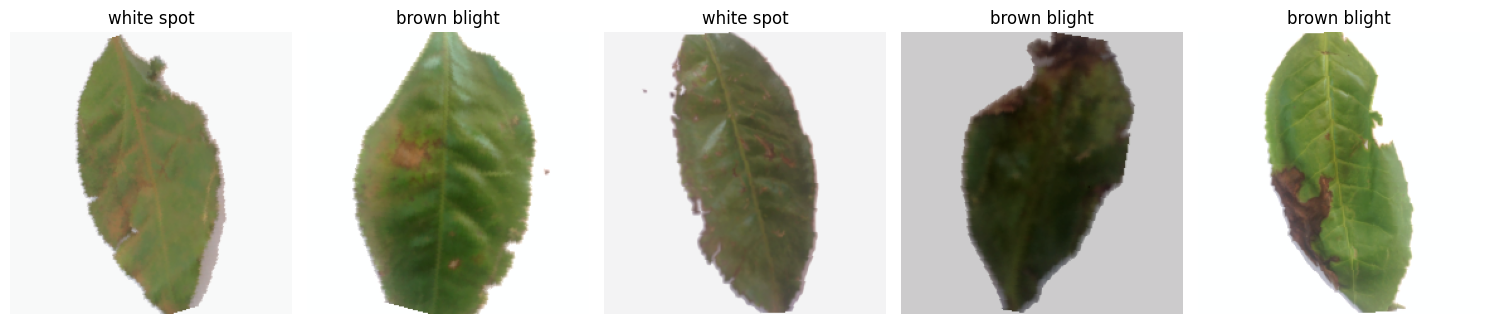

In [3]:
visualize_augmented_samples(train_dataset, num_samples=5)

## STEP 2 — MODEL 1: VGG16

In [4]:
import torch.nn as nn
import torchvision.models as models

# Check for GPU and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class VGG16(nn.Module):
    def __init__(self, num_classes=3):
        super(VGG16, self).__init__()
        # Load pre-trained VGG16 model using the recommended 'weights' argument
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Freeze all feature layers
        for param in vgg.features.parameters():
            param.requires_grad = False

        # Replace the classifier
        # The original VGG16 classifier is (25088 -> 4096 -> 4096 -> 1000)
        # We need to adapt the first layer to match the output of vgg.features (512 * 7 * 7 = 25088 for 224x224 input)
        # And the final layer to match num_classes
        vgg.classifier = nn.Sequential(
            nn.Linear(vgg.classifier[0].in_features, 512), # First layer in original classifier
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(512, 256), # Second layer
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes) # Output layer for our 3 classes
        )
        self.features = vgg.features
        self.classifier = vgg.classifier

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) # Flatten the features for the classifier
        x = self.classifier(x)
        return x

# Instantiate the VGG16 model
vgg16_model = VGG16(num_classes=len(class_names)).to(device)
print("VGG16 model initialized with pretrained weights and custom classifier.")
print(f"Number of trainable parameters: {sum(p.numel() for p in vgg16_model.parameters() if p.requires_grad)}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 174MB/s]


VGG16 model initialized with pretrained weights and custom classifier.
Number of trainable parameters: 12977667


In [5]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.notebook import tqdm
import time
import copy
import json

# Data loaders (assuming batch_size=32 for now, can be adjusted)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train DataLoader: {len(train_loader)} batches")
print(f"Validation DataLoader: {len(val_loader)} batches")
print(f"Test DataLoader: {len(test_loader)} batches")

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=25, patience=5, model_name="vgg16"):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    epochs_no_improve = 0

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in tqdm(dataloader, desc=f'{phase} phase'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                history['lr'].append(optimizer.param_groups[0]['lr'])
            else: # val
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                # Step the scheduler only on validation loss
                scheduler.step(epoch_loss)

                # deep copy the model if it's the best performing model based on validation accuracy
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    print(f"EarlyStopping counter: {epochs_no_improve} out of {patience}")
                    if epochs_no_improve == patience:
                        print(f"Early stopping triggered after {epoch+1} epochs!")
                        time_elapsed = time.time() - since
                        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
                        print(f'Best val Acc: {best_acc:4f}')
                        model.load_state_dict(best_model_wts)
                        return model, history

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Define Loss Function
criterion = nn.CrossEntropyLoss()

# Define Optimizer for VGG16 (only training classifier layers)
optimizer_vgg16 = optim.AdamW(vgg16_model.classifier.parameters(), lr=1e-4)

# Define Learning Rate Scheduler
scheduler_vgg16 = ReduceLROnPlateau(optimizer_vgg16, mode='min', factor=0.1, patience=3)

print("Starting VGG16 training...")
vgg16_model_trained, vgg16_history = train_model(
    vgg16_model, train_loader, val_loader, criterion, optimizer_vgg16, scheduler_vgg16,
    num_epochs=50, patience=5, model_name="vgg16"
)

# Save the best VGG16 model
model_save_path = os.path.join(MODELS_PATH, 'vgg16_best.pth')
torch.save(vgg16_model_trained.state_dict(), model_save_path)
print(f"Best VGG16 model saved to {model_save_path}")

# Save training history for VGG16
history_save_path = os.path.join(LOGS_PATH, 'vgg16_training_history.json')
# Convert history values to float if they are tensors/numpy for JSON serialization
for key in vgg16_history:
    if isinstance(vgg16_history[key], list):
        vgg16_history[key] = [x.item() if isinstance(x, torch.Tensor) else x for x in vgg16_history[key]]

with open(history_save_path, 'w') as f:
    json.dump(vgg16_history, f)
print(f"VGG16 training history saved to {history_save_path}")


Train DataLoader: 7 batches
Validation DataLoader: 3 batches
Test DataLoader: 3 batches
Starting VGG16 training...
Epoch 0/49
----------


train phase:   0%|          | 0/7 [00:00<?, ?it/s]

train Loss: 1.1100 Acc: 0.3273


val phase:   0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 1.0453 Acc: 0.4324
Epoch 1/49
----------


...

val Loss: 0.4063 Acc: 0.8243
EarlyStopping counter: 4 out of 5
Epoch 28/49
----------


train phase:   0%|          | 0/7 [00:00<?, ?it/s]

train Loss: 0.2557 Acc: 0.9273


val phase:   0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.4244 Acc: 0.7973
EarlyStopping counter: 5 out of 5
Early stopping triggered after 29 epochs!
Training complete in 5m 19s
Best val Acc: 0.864865
Best VGG16 model saved to /content/drive/MyDrive/CNNs and Transfer Learning/models/vgg16_best.pth
VGG16 training history saved to /content/drive/MyDrive/CNNs and Transfer Learning/logs/vgg16_training_history.json


## STEP 3 — MODEL 2: ResNet50

In [6]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, LinearLR, SequentialLR
import os
import json

# ──────────────────────────────────────────────────────────────────────────────
# Device (assumed already defined, kept for standalone safety)
# ──────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ──────────────────────────────────────────────────────────────────────────────
# Model  (same class name / __init__ signature / forward signature)
# ──────────────────────────────────────────────────────────────────────────────
class ResNet50(nn.Module):
    def __init__(self, num_classes=3):
        super(ResNet50, self).__init__()

        # Load pretrained ResNet50 (weights= API avoids deprecation warning)
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)  # V2 → better baseline

        # Freeze everything initially
        for param in resnet.parameters():
            param.requires_grad = False

        # ── Improved classifier head ──────────────────────────────────────────
        # Lower dropout (0.3 instead of 0.5) + BatchNorm + two-layer head
        # gives better gradient flow and regularisation for fine-tuning
        num_ftrs = resnet.fc.in_features          # 2048
        resnet.fc = nn.Sequential(
            nn.BatchNorm1d(num_ftrs),             # stabilises activations from frozen backbone
            nn.Dropout(0.3),                      # softer dropout — less information loss
            nn.Linear(num_ftrs, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

        self.model = resnet

    def forward(self, x):                         # ← signature unchanged
        return self.model(x)


# ──────────────────────────────────────────────────────────────────────────────
# Instantiate
# ──────────────────────────────────────────────────────────────────────────────
resnet50_model = ResNet50(num_classes=len(class_names)).to(device)
print("ResNet50 model initialised with IMAGENET1K_V2 weights and improved classifier head.")

print(f"Trainable params (Stage 1 – head only): "
      f"{sum(p.numel() for p in resnet50_model.parameters() if p.requires_grad):,}")


# ──────────────────────────────────────────────────────────────────────────────
# Loss  — label smoothing reduces overconfidence and closes the gap between
#         training and validation accuracy
# ──────────────────────────────────────────────────────────────────────────────
criterion_resnet = nn.CrossEntropyLoss(label_smoothing=0.1)


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 1 — train head only
#   • Warmup for 3 epochs then cosine anneal → avoids large early gradients
#     that can corrupt the frozen backbone's batch-norm running statistics
# ══════════════════════════════════════════════════════════════════════════════
optimizer_resnet_stage1 = optim.AdamW(
    resnet50_model.model.fc.parameters(),
    lr=1e-3,          # higher start — head is randomly initialised
    weight_decay=1e-4
)

warmup_s1   = LinearLR(optimizer_resnet_stage1, start_factor=0.1, end_factor=1.0, total_iters=3)
cosine_s1   = CosineAnnealingLR(optimizer_resnet_stage1, T_max=47, eta_min=1e-6)
scheduler_resnet_stage1 = SequentialLR(
    optimizer_resnet_stage1, schedulers=[warmup_s1, cosine_s1], milestones=[3]
)

# ── keep ReduceLROnPlateau as a safety net on top (passed to train_model) ─────
# If your train_model only accepts one scheduler, swap this for scheduler_resnet_stage1
plateau_s1 = ReduceLROnPlateau(optimizer_resnet_stage1, mode='min', factor=0.5, patience=5)

print("Starting ResNet50 Stage 1 training (head only) …")
resnet50_model_stage1_trained, resnet50_history_stage1 = train_model(
    resnet50_model, train_loader, val_loader,
    criterion_resnet, optimizer_resnet_stage1, plateau_s1,
    num_epochs=20,   # fewer epochs — head converges fast; saves budget for fine-tuning
    patience=7,
    model_name="resnet50_stage1"
)
print("\nStage 1 complete.")


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 2 — unfreeze layer4 + train head+layer4
# ══════════════════════════════════════════════════════════════════════════════
for param in resnet50_model_stage1_trained.model.layer4.parameters():
    param.requires_grad = True

print(f"Trainable params (Stage 2 – head + layer4): "
      f"{sum(p.numel() for p in resnet50_model_stage1_trained.parameters() if p.requires_grad):,}")

optimizer_resnet_stage2 = optim.AdamW(
    [
        {'params': resnet50_model_stage1_trained.model.fc.parameters(),     'lr': 1e-4},
        {'params': resnet50_model_stage1_trained.model.layer4.parameters(), 'lr': 5e-5},
    ],
    weight_decay=1e-4
)
scheduler_resnet_stage2 = ReduceLROnPlateau(
    optimizer_resnet_stage2, mode='min', factor=0.5, patience=5
)

print("Starting Stage 2 …")
resnet50_model_trained_stage2, resnet50_history_stage2 = train_model(
    resnet50_model_stage1_trained, train_loader, val_loader,
    criterion_resnet, optimizer_resnet_stage2, scheduler_resnet_stage2,
    num_epochs=30, patience=8, model_name="resnet50_stage2"
)
print("\nStage 2 complete.")


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — unfreeze layer3
# ══════════════════════════════════════════════════════════════════════════════
for param in resnet50_model_trained_stage2.model.layer3.parameters():
    param.requires_grad = True

print(f"Trainable params (Stage 3 – head + layer3 + layer4): "
      f"{sum(p.numel() for p in resnet50_model_trained_stage2.parameters() if p.requires_grad):,}")

optimizer_resnet_stage3 = optim.AdamW(
    [
        {'params': resnet50_model_trained_stage2.model.fc.parameters(),     'lr': 5e-5},
        {'params': resnet50_model_trained_stage2.model.layer4.parameters(), 'lr': 2e-5},
        {'params': resnet50_model_trained_stage2.model.layer3.parameters(), 'lr': 1e-5},
    ],
    weight_decay=1e-4
)
scheduler_resnet_stage3 = ReduceLROnPlateau(
    optimizer_resnet_stage3, mode='min', factor=0.5, patience=5
)

print("Starting Stage 3 …")
resnet50_model_trained_stage3, resnet50_history_stage3 = train_model(
    resnet50_model_trained_stage2, train_loader, val_loader,
    criterion_resnet, optimizer_resnet_stage3, scheduler_resnet_stage3,
    num_epochs=30, patience=8, model_name="resnet50_stage3"
)
print("\nStage 3 complete.")


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 4 — unfreeze layer1 + layer2  (conv1/bn1 stay frozen)
# ══════════════════════════════════════════════════════════════════════════════
for param in resnet50_model_trained_stage3.model.layer2.parameters():
    param.requires_grad = True
for param in resnet50_model_trained_stage3.model.layer1.parameters():
    param.requires_grad = True

print(f"Trainable params (Stage 4 – all layers): "
      f"{sum(p.numel() for p in resnet50_model_trained_stage3.parameters() if p.requires_grad):,}")

optimizer_resnet_stage4 = optim.AdamW(
    [
        {'params': resnet50_model_trained_stage3.model.fc.parameters(),     'lr': 2e-5},
        {'params': resnet50_model_trained_stage3.model.layer4.parameters(), 'lr': 5e-6},
        {'params': resnet50_model_trained_stage3.model.layer3.parameters(), 'lr': 2e-6},
        {'params': resnet50_model_trained_stage3.model.layer2.parameters(), 'lr': 1e-6},
        {'params': resnet50_model_trained_stage3.model.layer1.parameters(), 'lr': 5e-7},
    ],
    weight_decay=1e-4
)
# Cosine annealing for final stage — smooth decay to a clean minimum
scheduler_resnet_stage4 = CosineAnnealingLR(
    optimizer_resnet_stage4, T_max=30, eta_min=1e-8
)

print("Starting Stage 4 …")
resnet50_model_trained, resnet50_history_stage4 = train_model(
    resnet50_model_trained_stage3, train_loader, val_loader,
    criterion_resnet, optimizer_resnet_stage4, scheduler_resnet_stage4,
    num_epochs=30, patience=10, model_name="resnet50_stage4"
)
print("\nStage 4 complete.")


# ──────────────────────────────────────────────────────────────────────────────
# Combine histories  (same structure as original)
# ──────────────────────────────────────────────────────────────────────────────
resnet50_total_history = resnet50_history_stage1.copy()
for key in resnet50_total_history:
    resnet50_total_history[key].extend(resnet50_history_stage2[key])
    resnet50_total_history[key].extend(resnet50_history_stage3[key])
    resnet50_total_history[key].extend(resnet50_history_stage4[key])

# ──────────────────────────────────────────────────────────────────────────────
# Save model + history  (paths / logic unchanged)
# ──────────────────────────────────────────────────────────────────────────────
model_save_path_resnet = os.path.join(MODELS_PATH, 'resnet50_best.pth')
torch.save(resnet50_model_trained.state_dict(), model_save_path_resnet)
print(f"Best ResNet50 model saved to {model_save_path_resnet}")

history_save_path_resnet = os.path.join(LOGS_PATH, 'resnet50_training_history.json')
for key in resnet50_total_history:
    if isinstance(resnet50_total_history[key], list):
        resnet50_total_history[key] = [
            x.item() if isinstance(x, torch.Tensor) else float(x)
            for x in resnet50_total_history[key]
        ]

with open(history_save_path_resnet, 'w') as f:
    json.dump(resnet50_total_history, f)
print(f"ResNet50 training history saved to {history_save_path_resnet}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


ResNet50 model initialised with IMAGENET1K_V2 weights and improved classifier head.
Trainable params (Stage 1 – head only): 1,055,747
Starting ResNet50 Stage 1 training (head only) …
Epoch 0/19
----------


train phase:   0%|          | 0/7 [00:00<?, ?it/s]

train Loss: 1.1154 Acc: 0.4364


...

val Loss: 0.5643 Acc: 0.8784
EarlyStopping counter: 9 out of 10
Epoch 14/29
----------


train phase:   0%|          | 0/7 [00:00<?, ?it/s]

train Loss: 0.4426 Acc: 0.9364


val phase:   0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.5687 Acc: 0.8784
EarlyStopping counter: 10 out of 10
Early stopping triggered after 15 epochs!
Training complete in 2m 39s
Best val Acc: 0.918919

Stage 4 complete.
Best ResNet50 model saved to /content/drive/MyDrive/CNNs and Transfer Learning/models/resnet50_best.pth
ResNet50 training history saved to /content/drive/MyDrive/CNNs and Transfer Learning/logs/resnet50_training_history.json


## Step 5: Model Evaluation and Comparison


--- Evaluating VGG16 Model ---
Evaluating model...
Test Loss: 0.4818 Acc: 0.7838
VGG16 Classification Report:
{
    "algal leaf": {
        "precision": 0.7083333333333334,
        "recall": 0.7391304347826086,
        "f1-score": 0.723404255319149,
        "support": 23.0
    },
    "brown blight": {
        "precision": 0.8823529411764706,
        "recall": 0.6521739130434783,
        "f1-score": 0.75,
        "support": 23.0
    },
    "white spot": {
        "precision": 0.7878787878787878,
        "recall": 0.9285714285714286,
        "f1-score": 0.8524590163934426,
        "support": 28.0
    },
    "accuracy": 0.7837837837837838,
    "macro avg": {
        "precision": 0.7928550207961974,
        "recall": 0.7732919254658386,
        "f1-score": 0.7752877572375305,
        "support": 74.0
    },
    "weighted avg": {
        "precision": 0.7925187888423182,
        "recall": 0.7837837837837838,
        "f1-score": 0.780502031504822,
        "support": 74.0
    }
}


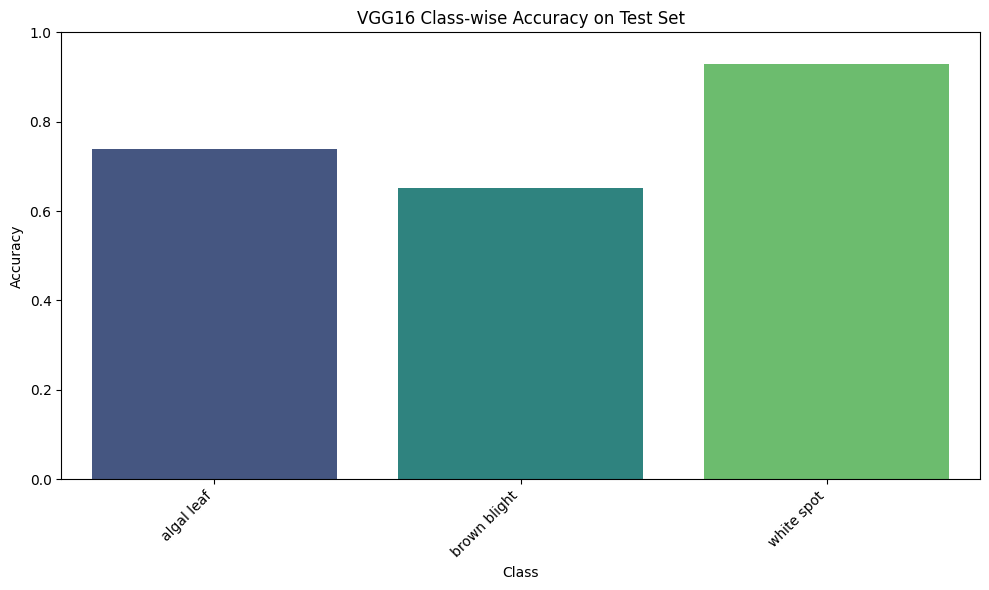

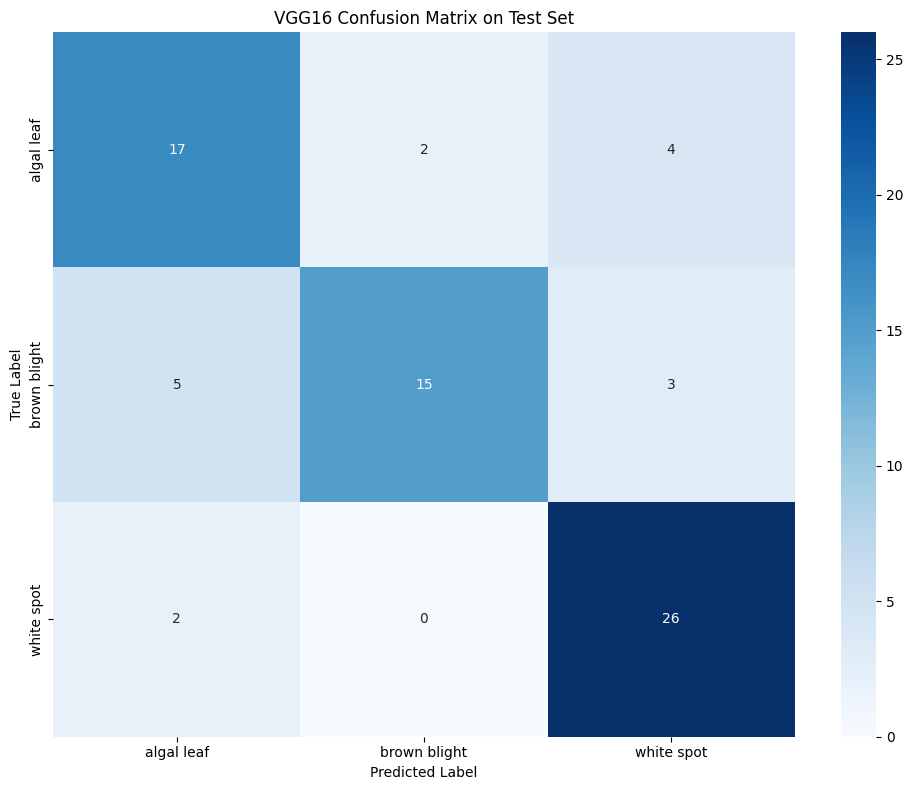

VGG16 evaluation report saved to /content/drive/MyDrive/CNNs and Transfer Learning/outputs/vgg16_report.json

--- Evaluating ResNet50 Model ---
Evaluating model...
Test Loss: 0.6016 Acc: 0.8649
ResNet50 Classification Report:
{
    "algal leaf": {
        "precision": 0.9,
        "recall": 0.782608695652174,
        "f1-score": 0.8372093023255814,
        "support": 23.0
    },
    "brown blight": {
        "precision": 0.84,
        "recall": 0.9130434782608695,
        "f1-score": 0.875,
        "support": 23.0
    },
    "white spot": {
        "precision": 0.8620689655172413,
        "recall": 0.8928571428571429,
        "f1-score": 0.8771929824561403,
        "support": 28.0
    },
    "accuracy": 0.8648648648648649,
    "macro avg": {
        "precision": 0.8673563218390804,
        "recall": 0.8628364389233955,
        "f1-score": 0.8631340949272407,
        "support": 74.0
    },
    "weighted avg": {
        "precision": 0.8669990680335508,
        "recall": 0.864864864864864

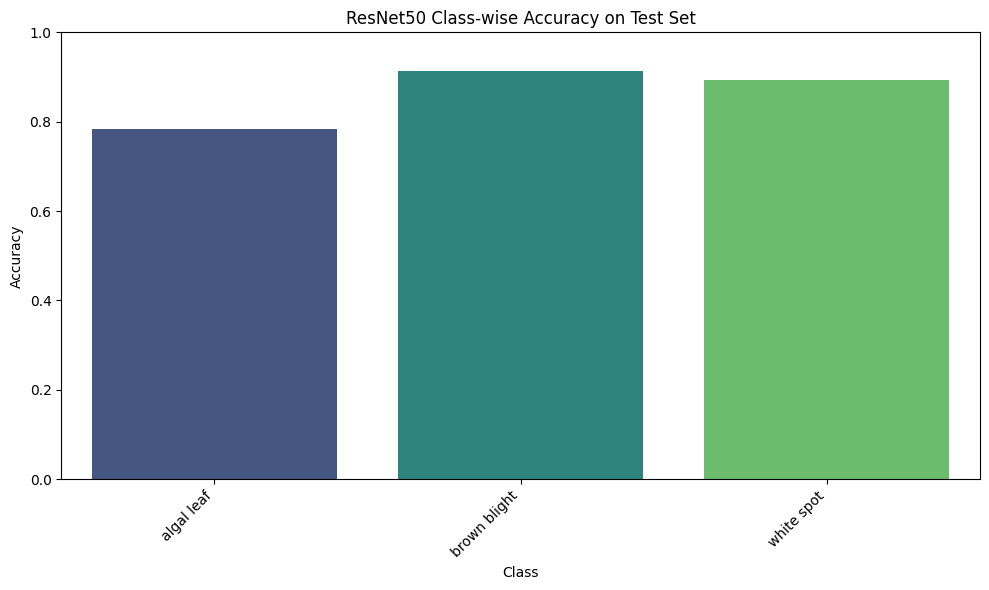

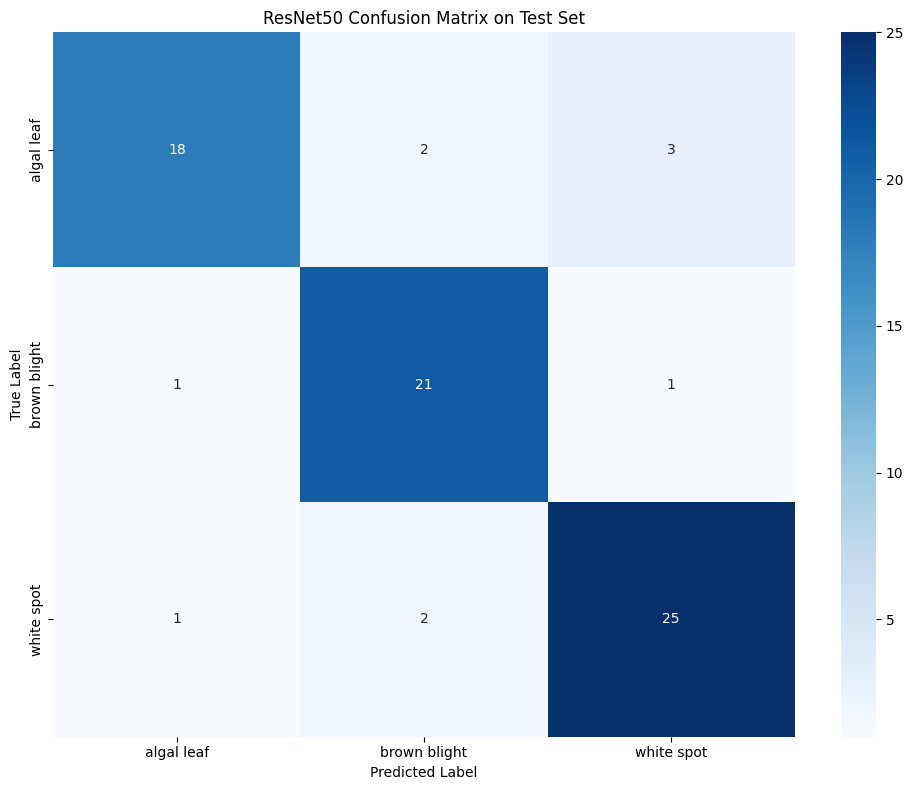

ResNet50 evaluation report saved to /content/drive/MyDrive/CNNs and Transfer Learning/outputs/resnet50_report.json

--- Model Comparison Summary ---
{
    "VGG16": {
        "Accuracy": 0.7837837837837838,
        "Loss": 0.48180348083779617
    },
    "ResNet50": {
        "Accuracy": 0.8648648648648649,
        "Loss": 0.6015602269688168
    }
}


| Model    | Test Accuracy | Test Loss |
|----------|---------------|-----------|
| VGG16    | 0.7838        | 0.4818    |
| ResNet50 | 0.8649        | 0.6016    |



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import json
import numpy as np

# Ensure the device is consistent
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate_model(model, dataloader, criterion, device, class_names):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    running_corrects = 0
    all_preds = []
    all_labels = []

    print("Evaluating model...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)

    print(f'Test Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    # Calculate class-wise accuracy
    cm = confusion_matrix(all_labels, all_preds)
    class_accuracies = cm.diagonal() / cm.sum(axis=1)

    # Create a classification report
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

    return epoch_loss, epoch_acc.item(), class_accuracies, cm, report

def plot_class_accuracy(class_names, class_accuracies, model_name, save_path=None):
    plt.figure(figsize=(10, 6))
    # Fix for Seaborn FutureWarning: assign x to hue and set legend=False
    sns.barplot(x=class_names, y=class_accuracies, hue=class_names, palette='viridis', legend=False)
    plt.title(f'{model_name} Class-wise Accuracy on Test Set')
    plt.xlabel('Class')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save_path: plt.savefig(save_path)
    plt.show()

def plot_confusion_matrix(cm, class_names, model_name, save_path=None):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix on Test Set')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    if save_path: plt.savefig(save_path)
    plt.show()

# --- VGG16 Model Evaluation ---
print("\n--- Evaluating VGG16 Model ---")
vgg16_model_eval = VGG16(num_classes=len(class_names)).to(device)
vgg16_model_eval.load_state_dict(torch.load(os.path.join(MODELS_PATH, 'vgg16_best.pth')))

vgg16_loss, vgg16_acc, vgg16_class_accuracies, vgg16_cm, vgg16_report = evaluate_model(
    vgg16_model_eval, test_loader, criterion, device, class_names
)

print("VGG16 Classification Report:")
print(json.dumps(vgg16_report, indent=4))

plot_class_accuracy(class_names, vgg16_class_accuracies, "VGG16", os.path.join(OUTPUTS_PATH, 'vgg16_class_accuracy.png'))
plot_confusion_matrix(vgg16_cm, class_names, "VGG16", os.path.join(OUTPUTS_PATH, 'vgg16_confusion_matrix.png'))

# Save VGG16 report
with open(os.path.join(OUTPUTS_PATH, 'vgg16_report.json'), 'w') as f:
    json.dump(vgg16_report, f, indent=4)
print(f"VGG16 evaluation report saved to {os.path.join(OUTPUTS_PATH, 'vgg16_report.json')}")

# --- ResNet50 Model Evaluation ---
print("\n--- Evaluating ResNet50 Model ---")
# Make sure to instantiate the ResNet50 model with the same architecture it was trained with
resnet50_model_eval = ResNet50(num_classes=len(class_names)).to(device)
resnet50_model_eval.load_state_dict(torch.load(os.path.join(MODELS_PATH, 'resnet50_best.pth')))

resnet50_loss, resnet50_acc, resnet50_class_accuracies, resnet50_cm, resnet50_report = evaluate_model(
    resnet50_model_eval, test_loader, criterion_resnet, device, class_names
)

print("ResNet50 Classification Report:")
print(json.dumps(resnet50_report, indent=4))

plot_class_accuracy(class_names, resnet50_class_accuracies, "ResNet50", os.path.join(OUTPUTS_PATH, 'resnet50_class_accuracy.png'))
plot_confusion_matrix(resnet50_cm, class_names, "ResNet50", os.path.join(OUTPUTS_PATH, 'resnet50_confusion_matrix.png'))

# Save ResNet50 report
with open(os.path.join(OUTPUTS_PATH, 'resnet50_report.json'), 'w') as f:
    json.dump(resnet50_report, f, indent=4)
print(f"ResNet50 evaluation report saved to {os.path.join(OUTPUTS_PATH, 'resnet50_report.json')}")

# --- Overall Comparison --- (Optional, can be a separate cell if preferred)
print("\n--- Model Comparison Summary ---")
comparison_data = {
    "VGG16": {"Accuracy": vgg16_acc, "Loss": vgg16_loss},
    "ResNet50": {"Accuracy": resnet50_acc, "Loss": resnet50_loss}
}
print(json.dumps(comparison_data, indent=4))

# Create a simple comparison table markdown
comparison_table = """
| Model    | Test Accuracy | Test Loss |
|----------|---------------|-----------|
| VGG16    | {:.4f}        | {:.4f}    |
| ResNet50 | {:.4f}        | {:.4f}    |
""".format(vgg16_acc, vgg16_loss, resnet50_acc, resnet50_loss)

print("\n" + comparison_table)

## STEP 6: Plotting Training Curves

In [ ]:
import matplotlib.pyplot as plt
import json
import os

def plot_training_history(history, model_name, save_path=None):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Training curve for {model_name} saved to {save_path}")
    plt.show()

# --- Plot VGG16 Training History ---
vgg16_history_path = os.path.join(LOGS_PATH, 'vgg16_training_history.json')
if os.path.exists(vgg16_history_path):
    with open(vgg16_history_path, 'r') as f:
        vgg16_history = json.load(f)
    print("\n--- VGG16 Training Curves ---")
    plot_training_history(vgg16_history, "VGG16", os.path.join(OUTPUTS_PATH, 'vgg16_training_curve.png'))
else:
    print(f"VGG16 training history not found at {vgg16_history_path}")

# --- Plot ResNet50 Training History ---
resnet50_history_path = os.path.join(LOGS_PATH, 'resnet50_training_history.json')
if os.path.exists(resnet50_history_path):
    with open(resnet50_history_path, 'r') as f:
        resnet50_history = json.load(f)
    print("\n--- ResNet50 Training Curves ---")
    plot_training_history(resnet50_history, "ResNet50", os.path.join(OUTPUTS_PATH, 'resnet50_training_curve.png'))
else:
    print(f"ResNet50 training history not found at {resnet50_history_path}")

## STEP 6: Class-wise Intelligent Weighting

In [9]:
import json
import os
import numpy as np

def compute_hybrid_weights(vgg16_report, resnet50_report, class_names):
    hybrid_weights = {}
    for class_name in class_names:
        vgg16_f1 = vgg16_report[class_name]['f1-score']
        resnet50_f1 = resnet50_report[class_name]['f1-score']

        # Handle cases where f1-score might be zero for a class (though unlikely with good training)
        total_f1 = vgg16_f1 + resnet50_f1
        if total_f1 == 0:
            # If both are zero, assign equal weight or default to 0.5
            vgg16_weight = 0.5
            resnet50_weight = 0.5
        else:
            vgg16_weight = vgg16_f1 / total_f1
            resnet50_weight = resnet50_f1 / total_f1

        hybrid_weights[class_name] = {
            'VGG16_weight': vgg16_weight,
            'ResNet50_weight': resnet50_weight
        }
    return hybrid_weights

# Load reports (assuming they are saved in OUTPUTS_PATH from previous steps)
vgg16_report_path = os.path.join(OUTPUTS_PATH, 'vgg16_report.json')
resnet50_report_path = os.path.join(OUTPUTS_PATH, 'resnet50_report.json')

vgg16_report = None
resnet50_report = None

if os.path.exists(vgg16_report_path):
    with open(vgg16_report_path, 'r') as f:
        vgg16_report = json.load(f)
    print(f"Loaded VGG16 report from {vgg16_report_path}")
else:
    print(f"VGG16 report not found at {vgg16_report_path}")

if os.path.exists(resnet50_report_path):
    with open(resnet50_report_path, 'r') as f:
        resnet50_report = json.load(f)
    print(f"Loaded ResNet50 report from {resnet50_report_path}")
else:
    print(f"ResNet50 report not found at {resnet50_report_path}")


if vgg16_report and resnet50_report:
    # class_names should already be defined from previous data loading steps
    print("\n--- Computing Hybrid Weights ---")
    hybrid_weights = compute_hybrid_weights(vgg16_report, resnet50_report, class_names)

    hybrid_weights_path = os.path.join(CONFIGS_PATH, 'hybrid_weights.json')
    with open(hybrid_weights_path, 'w') as f:
        json.dump(hybrid_weights, f, indent=4)
    print(f"Hybrid weights saved to {hybrid_weights_path}")

    print("\nHybrid Weights per Class:")
    print(json.dumps(hybrid_weights, indent=4))
else:
    print("Cannot compute hybrid weights: One or both model reports are missing.")

Loaded VGG16 report from /content/drive/MyDrive/CNNs and Transfer Learning/outputs/vgg16_report.json
Loaded ResNet50 report from /content/drive/MyDrive/CNNs and Transfer Learning/outputs/resnet50_report.json

--- Computing Hybrid Weights ---
Hybrid weights saved to /content/drive/MyDrive/CNNs and Transfer Learning/configs/hybrid_weights.json

Hybrid Weights per Class:
{
    "algal leaf": {
        "VGG16_weight": 0.4635383639822448,
        "ResNet50_weight": 0.5364616360177552
    },
    "brown blight": {
        "VGG16_weight": 0.46153846153846156,
        "ResNet50_weight": 0.5384615384615384
    },
    "white spot": {
        "VGG16_weight": 0.4928500166278683,
        "ResNet50_weight": 0.5071499833721317
    }
}


## STEP 7: Hybrid Ensemble Inference

In [10]:
import torch
import torch.nn as nn
import json
import os

# Ensure class_names is available
if 'class_names' not in locals():
    # This part should ideally not be needed if previous cells were run
    # but included for robustness if running this cell in isolation.
    from torchvision import datasets
    full_dataset = datasets.ImageFolder(root=DATA_PATH)
    class_names = full_dataset.classes

# Load the best trained VGG16 model
vgg16_model_eval = VGG16(num_classes=len(class_names)).to(device)
vgg16_model_eval.load_state_dict(torch.load(os.path.join(MODELS_PATH, 'vgg16_best.pth')))
vgg16_model_eval.eval() # Set to evaluation mode
print("Loaded best VGG16 model.")

# Load the best trained ResNet50 model
resnet50_model_eval = ResNet50(num_classes=len(class_names)).to(device)
resnet50_model_eval.load_state_dict(torch.load(os.path.join(MODELS_PATH, 'resnet50_best.pth')))
resnet50_model_eval.eval() # Set to evaluation mode
print("Loaded best ResNet50 model.")

# Load hybrid weights
hybrid_weights_path = os.path.join(CONFIGS_PATH, 'hybrid_weights.json')
if os.path.exists(hybrid_weights_path):
    with open(hybrid_weights_path, 'r') as f:
        hybrid_weights_json = json.load(f)
    print("Loaded hybrid weights.")
else:
    raise FileNotFoundError(f"Hybrid weights not found at {hybrid_weights_path}")

# Convert hybrid weights from JSON structure to a dictionary of tensors for easier use
class_to_idx = {name: i for i, name in enumerate(class_names)}
hybrid_weights_tensor = {
    'VGG16': torch.zeros(len(class_names), device=device),
    'ResNet50': torch.zeros(len(class_names), device=device)
}

for class_name, weights in hybrid_weights_json.items():
    idx = class_to_idx[class_name]
    hybrid_weights_tensor['VGG16'][idx] = torch.tensor(weights['VGG16_weight'], device=device)
    hybrid_weights_tensor['ResNet50'][idx] = torch.tensor(weights['ResNet50_weight'], device=device)

print("Hybrid weights converted to tensors.")

Loaded best VGG16 model.
Loaded best ResNet50 model.
Loaded hybrid weights.
Hybrid weights converted to tensors.


In [11]:
class HybridEnsemble(nn.Module):
    def __init__(self, model1, model2, weights_tensor, num_classes):
        super(HybridEnsemble, self).__init__()
        self.model1 = model1
        self.model2 = model2
        self.weights_tensor = weights_tensor # Dictionary of tensors: {'VGG16': tensor, 'ResNet50': tensor}
        self.num_classes = num_classes
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        # Get raw logits from each model
        logits1 = self.model1(x)
        logits2 = self.model2(x)

        # Convert logits to probabilities
        probs1 = self.softmax(logits1)
        probs2 = self.softmax(logits2)

        # Apply class-wise weights
        weighted_probs1 = probs1 * self.weights_tensor['VGG16']
        weighted_probs2 = probs2 * self.weights_tensor['ResNet50']

        # Sum weighted probabilities for the ensemble prediction
        ensemble_probs = weighted_probs1 + weighted_probs2

        return ensemble_probs

# Instantiate the hybrid ensemble model
hybrid_ensemble_model = HybridEnsemble(
    vgg16_model_eval,
    resnet50_model_eval,
    hybrid_weights_tensor,
    num_classes=len(class_names)
).to(device)

print("Hybrid Ensemble model instantiated.")

Hybrid Ensemble model instantiated.


### Saving Hybrid Ensemble Configuration

Since the hybrid ensemble is a combination of pre-trained models and weights, we save its configuration rather than a single `state_dict`. This configuration will allow us to reconstruct the ensemble later.

In [12]:
hybrid_ensemble_config = {
    'model_type': 'HybridEnsemble',
    'model1_path': os.path.join(MODELS_PATH, 'vgg16_best.pth'),
    'model1_name': 'VGG16',
    'model2_path': os.path.join(MODELS_PATH, 'resnet50_best.pth'),
    'model2_name': 'ResNet50',
    'hybrid_weights_path': os.path.join(CONFIGS_PATH, 'hybrid_weights.json'),
    'class_names': class_names,
    'num_classes': len(class_names)
}

hybrid_config_save_path = os.path.join(CONFIGS_PATH, 'hybrid_ensemble_config.json')
with open(hybrid_config_save_path, 'w') as f:
    json.dump(hybrid_ensemble_config, f, indent=4)
print(f"Hybrid ensemble configuration saved to {hybrid_config_save_path}")

Hybrid ensemble configuration saved to /content/drive/MyDrive/CNNs and Transfer Learning/configs/hybrid_ensemble_config.json


## STEP 8: Hybrid Ensemble Model Evaluation


--- Evaluating Hybrid Ensemble Model ---
Evaluating model...
Test Loss: 0.7752 Acc: 0.9054
Hybrid Ensemble Classification Report:
{
    "algal leaf": {
        "precision": 0.9523809523809523,
        "recall": 0.8695652173913043,
        "f1-score": 0.9090909090909091,
        "support": 23.0
    },
    "brown blight": {
        "precision": 0.9090909090909091,
        "recall": 0.8695652173913043,
        "f1-score": 0.8888888888888888,
        "support": 23.0
    },
    "white spot": {
        "precision": 0.8709677419354839,
        "recall": 0.9642857142857143,
        "f1-score": 0.9152542372881356,
        "support": 28.0
    },
    "accuracy": 0.9054054054054054,
    "macro avg": {
        "precision": 0.9108132011357818,
        "recall": 0.9011387163561076,
        "f1-score": 0.9044113450893111,
        "support": 74.0
    },
    "weighted avg": {
        "precision": 0.908120940379005,
        "recall": 0.9054054054054054,
        "f1-score": 0.905143972940583,
        "su

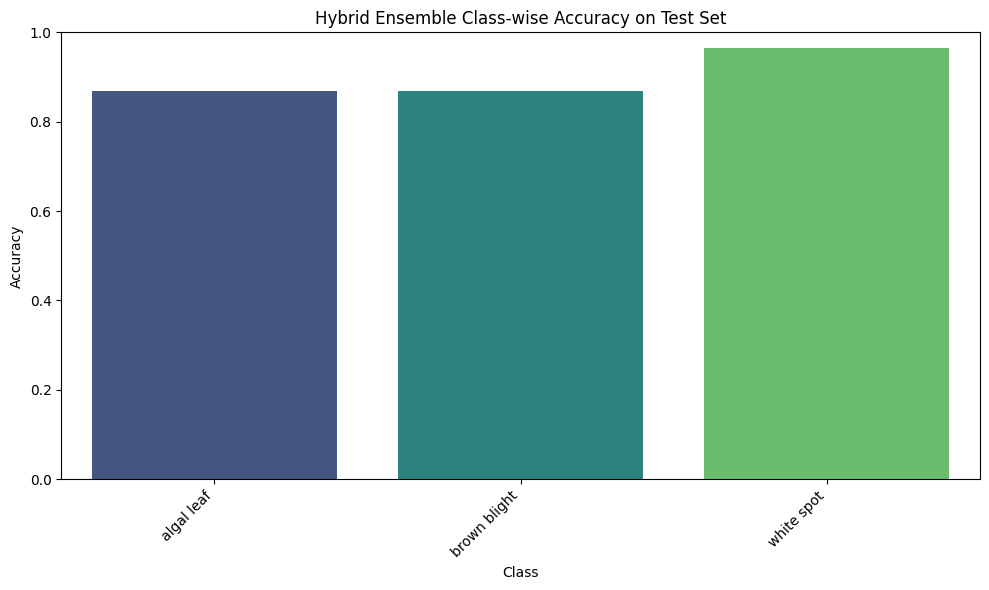

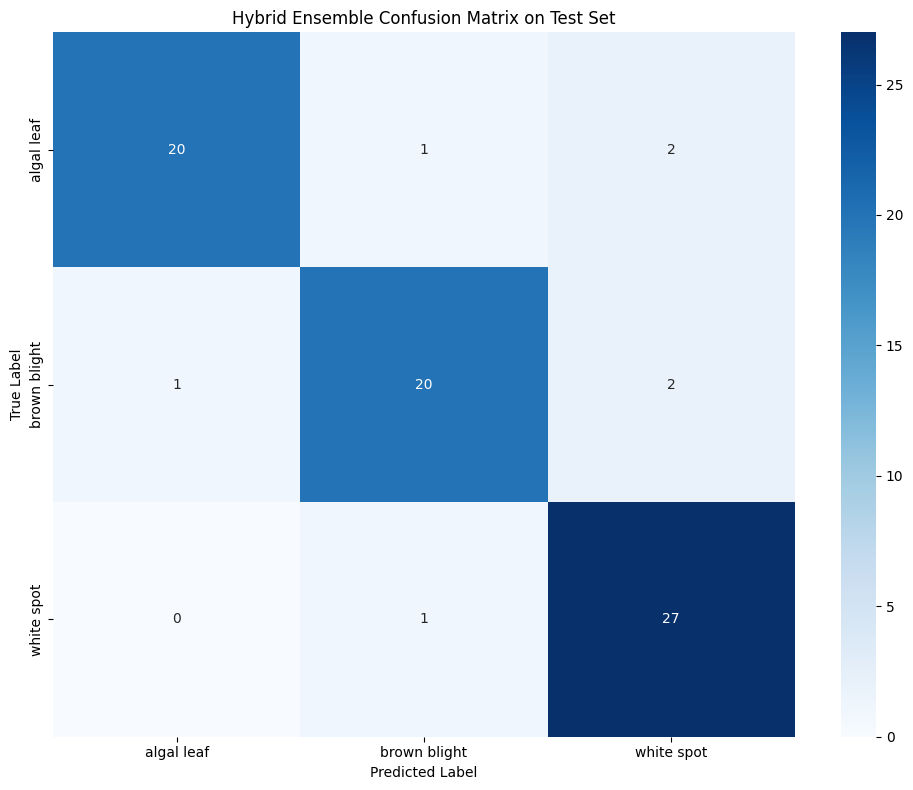

Hybrid Ensemble evaluation report saved to /content/drive/MyDrive/CNNs and Transfer Learning/outputs/hybrid_ensemble_report.json

--- Updated Model Comparison Summary ---


| Model         | Test Accuracy | Test Loss |
|---------------|---------------|-----------|
| VGG16         | 0.7838        | 0.4818    |
| ResNet50      | 0.8649        | 0.6016    |
| Hybrid Ensemble | 0.9054        | 0.7752    |



In [13]:
# Evaluate the Hybrid Ensemble Model
print("\n--- Evaluating Hybrid Ensemble Model ---")
hybrid_ensemble_loss, hybrid_ensemble_acc, hybrid_ensemble_class_accuracies, hybrid_ensemble_cm, hybrid_ensemble_report = evaluate_model(
    hybrid_ensemble_model, test_loader, criterion, device, class_names
)

print("Hybrid Ensemble Classification Report:")
print(json.dumps(hybrid_ensemble_report, indent=4))

plot_class_accuracy(class_names, hybrid_ensemble_class_accuracies, "Hybrid Ensemble", os.path.join(OUTPUTS_PATH, 'hybrid_ensemble_class_accuracy.png'))
plot_confusion_matrix(hybrid_ensemble_cm, class_names, "Hybrid Ensemble", os.path.join(OUTPUTS_PATH, 'hybrid_ensemble_confusion_matrix.png'))

# Save Hybrid Ensemble report
hybrid_ensemble_report_path = os.path.join(OUTPUTS_PATH, 'hybrid_ensemble_report.json')
with open(hybrid_ensemble_report_path, 'w') as f:
    json.dump(hybrid_ensemble_report, f, indent=4)
print(f"Hybrid Ensemble evaluation report saved to {hybrid_ensemble_report_path}")

# --- Update Overall Comparison with Hybrid Ensemble ---
print("\n--- Updated Model Comparison Summary ---")
comparison_data["Hybrid Ensemble"] = {"Accuracy": hybrid_ensemble_acc, "Loss": hybrid_ensemble_loss}

# Create an updated comparison table markdown
updated_comparison_table = """
| Model         | Test Accuracy | Test Loss |
|---------------|---------------|-----------|
| VGG16         | {:.4f}        | {:.4f}    |
| ResNet50      | {:.4f}        | {:.4f}    |
| Hybrid Ensemble | {:.4f}        | {:.4f}    |
""".format(vgg16_acc, vgg16_loss, resnet50_acc, resnet50_loss, hybrid_ensemble_acc, hybrid_ensemble_loss)

print("\n" + updated_comparison_table)


## STEP 9: Generate README for Model Usage

In [14]:
readme_content = """# How to use the saved ResNet50 model (resnet50_best.pth)\n\nThis document explains how to load the pre-trained `resnet50_best.pth` model and use it to make predictions on new images.\n\n## 1. Setup and Imports\n\nFirst, ensure you have the necessary libraries installed and set up your environment.\n\n```python\nimport torch\nimport torch.nn as nn\nimport torchvision.models as models\nfrom torchvision import transforms\nfrom PIL import Image\nimport numpy as np\nimport os\nimport cv2 # For get_white_padded_centered_crop\n\n# Device setup\ndevice = torch.device(\"cuda\" if torch.cuda.is_available() else \"cpu\")\nprint(f\"Using device: {device}\")\n\n# ImageNet mean and standard deviation for normalization (must match training)\nIMAGENET_MEAN = [0.485, 0.456, 0.406]\nIMAGENET_STD = [0.229, 0.224, 0.225]\n\n# Class names (must match training)\nclass_names = ['algal leaf', 'brown blight', 'white spot'] # Adjust if your class names are different\n\n# Define the base project path as specified in training\nPROJECT_BASE_PATH = '/content/drive/MyDrive/CNNs and Transfer Learning'\nMODELS_PATH = os.path.join(PROJECT_BASE_PATH, 'models')\n\n# Define custom preprocessing function (must match training)\ndef get_white_padded_centered_crop(pil_image):\n    cv_img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)\n    img_h, img_w = cv_img.shape[:2]\n    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)\n    blur = cv2.GaussianBlur(gray, (7, 7), 0)\n    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)\n    kernel = np.ones((5, 5), np.uint8)\n    leaf_mask = cv2.dilate(thresh, kernel, iterations=2)\n    white_bg = np.full(cv_img.shape, 255, dtype=np.uint8)\n    cv_img_cleaned = np.where(leaf_mask[:, :, None] == 255, cv_img, white_bg)\n    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)\n    if not contours:\n        return pil_image\n    largest_cnt = max(contours, key=cv2.contourArea)\n    x, y, w, h = cv2.boundingRect(largest_cnt)\n    max_dim = max(w, h)\n    small_margin = int(max_dim * 0.02)\n    square_side = max_dim + (2 * small_margin)\n    canvas_side = max(img_w, img_h) + (square_side * 2)\n    canvas = np.full((canvas_side, canvas_side, 3), 255, dtype=np.uint8)\n    off_x = (canvas_side - img_w) // 2\n    off_y = (canvas_side - img_h) // 2\n    canvas[off_y:off_y+img_h, off_x:off_x+img_w] = cv_img_cleaned\n    obj_center_x = off_x + x + (w // 2)\n    obj_center_y = off_y + y + (h // 2)\n    left = obj_center_x - (square_side // 2)\n    top = obj_center_y - (square_side // 2)\n    final_crop = canvas[top:top+square_side, left:left+square_side]\n    return Image.fromarray(cv2.cvtColor(final_crop, cv2.COLOR_BGR2RGB))\n\n# Define the exact same transformations used during validation/testing\nval_test_transforms = transforms.Compose([\n    transforms.Lambda(get_white_padded_centered_crop),\n    transforms.Resize(256),\n    transforms.CenterCrop(224),\n    transforms.ToTensor(),\n    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)\n])\n\n```\n\n## 2. Model Architecture\n\nThe `ResNet50` class must be identical to the one used for training. Here is the definition:\n\n```python\nclass ResNet50(nn.Module):\n    def __init__(self, num_classes=3):\n        super(ResNet50, self).__init__ ()\n        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)\n        for param in resnet.parameters():\n            param.requires_grad = False\n        num_ftrs = resnet.fc.in_features\n        resnet.fc = nn.Sequential(\n            nn.BatchNorm1d(num_ftrs),\n            nn.Dropout(0.3),\n            nn.Linear(num_ftrs, 512),\n            nn.ReLU(inplace=True),\n            nn.BatchNorm1d(512),\n            nn.Dropout(0.2),\n            nn.Linear(512, num_classes)\n        )\n        self.model = resnet\n\n    def forward(self, x):\n        return self.model(x)\n```\n\n## 3. Load the Model\n\nLoad the state dictionary of the best-trained `ResNet50` model.\n\n```python\nmodel_path = os.path.join(MODELS_PATH, 'resnet50_best.pth')\n\n# Instantiate the model with the correct number of classes\nresnet50_model = ResNet50(num_classes=len(class_names)).to(device)\n\n# Load the saved state dictionary\nif os.path.exists(model_path):\n    resnet50_model.load_state_dict(torch.load(model_path, map_location=device))\n    resnet50_model.eval() # Set to evaluation mode\n    print(f\"ResNet50 model loaded successfully from {model_path}\")\nelse:\n    print(f\"Error: Model file not found at {model_path}\")\n\n```\n\n## 4. Make a Prediction on a New Image\n\nHere's how to preprocess a new image and get a prediction.\n\n```python\n# Example: Load a new image (replace with your actual image path)\n# For demonstration, let's create a dummy image or load from a sample path if available\n# \n# If you have a real image, replace this with:\n# image_path = 'path/to/your/new_image.jpg'\n# pil_image = Image.open(image_path).convert('RGB')\n\n# --- Dummy image creation for demonstration ---\n# This part assumes you have OpenCV to create a blank image, or you can skip to loading a real one.\n# Create a blank white image (e.g., 256x256 pixels)\ndummy_image_np = np.full((256, 256, 3), 255, dtype=np.uint8)\ndummy_image_pil = Image.fromarray(dummy_image_np)\n# --- End of dummy image creation ---\n\n# Use the dummy_image_pil or your actual loaded pil_image\ninput_image = val_test_transforms(dummy_image_pil).unsqueeze(0).to(device)\n\n# Perform inference\nwith torch.no_grad():\n    outputs = resnet50_model(input_image)\n    probabilities = torch.softmax(outputs, dim=1)\n    _, predicted = torch.max(outputs, 1)\n\npredicted_class_idx = predicted.item()\npredicted_class_name = class_names[predicted_class_idx]\nprediction_probability = probabilities[0, predicted_class_idx].item()\n\nprint(f\"Predicted class index: {predicted_class_idx}\")\nprint(f\"Predicted class name: {predicted_class_name}\")\nprint(f\"Prediction probability: {prediction_probability:.4f}\")\n\n```\n"""

In [15]:
# Write the content to a README.md file in the models directory
readme_file_path = os.path.join(MODELS_PATH, 'README.md')

with open(readme_file_path, 'w') as f:
    f.write(readme_content)

print(f"README.md has been created at: {readme_file_path}")

README.md has been created at: /content/drive/MyDrive/CNNs and Transfer Learning/models/README.md


## STEP 10: Model Inference Example

### 1. Setup and Imports

First, ensure you have the necessary libraries installed and set up your environment.

In [16]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import numpy as np
import os
import cv2 # For get_white_padded_centered_crop

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ImageNet mean and standard deviation for normalization (must match training)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Class names (must match training)
class_names = ['algal leaf', 'brown blight', 'white spot'] # Adjust if your class names are different

# Define the base project path as specified in training
PROJECT_BASE_PATH = '/content/drive/MyDrive/CNNs and Transfer Learning'
MODELS_PATH = os.path.join(PROJECT_BASE_PATH, 'models')

# Define custom preprocessing function (must match training)
def get_white_padded_centered_crop(pil_image):
    cv_img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    img_h, img_w = cv_img.shape[:2]
    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5, 5), np.uint8)
    leaf_mask = cv2.dilate(thresh, kernel, iterations=2)
    white_bg = np.full(cv_img.shape, 255, dtype=np.uint8)
    cv_img_cleaned = np.where(leaf_mask[:, :, None] == 255, cv_img, white_bg)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return pil_image
    largest_cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_cnt)
    max_dim = max(w, h)
    small_margin = int(max_dim * 0.02)
    square_side = max_dim + (2 * small_margin)
    canvas_side = max(img_w, img_h) + (square_side * 2)
    canvas = np.full((canvas_side, canvas_side, 3), 255, dtype=np.uint8)
    off_x = (canvas_side - img_w) // 2
    off_y = (canvas_side - img_h) // 2
    canvas[off_y:off_y+img_h, off_x:off_x+img_w] = cv_img_cleaned
    obj_center_x = off_x + x + (w // 2)
    obj_center_y = off_y + y + (h // 2)
    left = obj_center_x - (square_side // 2)
    top = obj_center_y - (square_side // 2)
    final_crop = canvas[top:top+square_side, left:left+square_side]
    return Image.fromarray(cv2.cvtColor(final_crop, cv2.COLOR_BGR2RGB))

# Define the exact same transformations used during validation/testing
val_test_transforms = transforms.Compose([
    transforms.Lambda(get_white_padded_centered_crop),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

Using device: cuda


### 2. Model Architecture

The `ResNet50` class must be identical to the one used for training. Here is the definition:

In [17]:
class ResNet50(nn.Module):
    def __init__(self, num_classes=3):
        super(ResNet50, self).__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        for param in resnet.parameters():
            param.requires_grad = False
        num_ftrs = resnet.fc.in_features
        resnet.fc = nn.Sequential(
            nn.BatchNorm1d(num_ftrs),
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        self.model = resnet

    def forward(self, x):
        return self.model(x)

### 3. Load the Model

Load the state dictionary of the best-trained `ResNet50` model.

In [18]:
model_path = os.path.join(MODELS_PATH, 'resnet50_best.pth')

# Instantiate the model with the correct number of classes
resnet50_model = ResNet50(num_classes=len(class_names)).to(device)

# Load the saved state dictionary
if os.path.exists(model_path):
    resnet50_model.load_state_dict(torch.load(model_path, map_location=device))
    resnet50_model.eval() # Set to evaluation mode
    print(f"ResNet50 model loaded successfully from {model_path}")
else:
    print(f"Error: Model file not found at {model_path}")

ResNet50 model loaded successfully from /content/drive/MyDrive/CNNs and Transfer Learning/models/resnet50_best.pth


### 4. Make a Prediction on a New Image

Here's how to preprocess a new image and get a prediction.

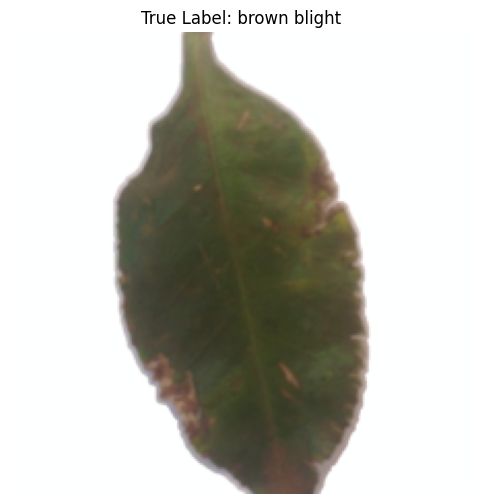

Predicted class index: 1
Predicted class name: brown blight
Prediction probability: 0.6288


In [19]:
import matplotlib.pyplot as plt

# --- Use a real image from the test_dataset ---
# Get a sample image and label from the test_dataset
# Let's pick the first image for demonstration
img_tensor, true_label_idx = test_dataset[0] # test_dataset is a Subset, already has transforms applied

# For displaying, we need to unnormalize and convert to PIL/numpy
# Note: img_tensor is already transformed, so we need to reverse normalization for display
img_display = img_tensor.clone().cpu().numpy().transpose((1, 2, 0)) # C, H, W to H, W, C
mean = np.array(IMAGENET_MEAN)
std = np.array(IMAGENET_STD)
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

# Visualize the image and its true label
plt.figure(figsize=(6, 6))
plt.imshow(img_display)
plt.title(f"True Label: {class_names[true_label_idx]}")
plt.axis('off')
plt.show()

# Prepare the image tensor for model input (add batch dimension and move to device)
input_image = img_tensor.unsqueeze(0).to(device)

# Perform inference
with torch.no_grad():
    outputs = resnet50_model(input_image)
    probabilities = torch.softmax(outputs, dim=1)
    _, predicted = torch.max(outputs, 1)

predicted_class_idx = predicted.item()
predicted_class_name = class_names[predicted_class_idx]
prediction_probability = probabilities[0, predicted_class_idx].item()

print(f"Predicted class index: {predicted_class_idx}")
print(f"Predicted class name: {predicted_class_name}")
print(f"Prediction probability: {prediction_probability:.4f}")